# **Installing requirements**

In [ ]:
!pip install cloudscraper beautifulsoup4 pandas seaborn matplotlib geopy scikit-learn xgboost tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 kB 6.8 MB/s eta 0:00:00


# **Scraping Avito Data**

In [ ]:
# STEP 1: Cloud Scrapping Avito Data
# ============================================================

import cloudscraper
from bs4 import BeautifulSoup
import pandas as pd
import time

cities = ['agadir', 'rabat', 'marrakech', 'tanger', 'casablanca']
pages_per_city = 200  # Pushing deep into the historical data
scraped_data = []

print("Starting the Deep Scraper...")
scraper = cloudscraper.create_scraper()

for city in cities:
    print(f"\n--- Scraping City: {city.upper()} ---")

    for page in range(1, pages_per_city + 1):

        print(f"\rScraping page: {page}/{pages_per_city}", end="")

        url = f"https://www.avito.ma/fr/{city}/appartements-%C3%A0_vendre?o={page}"
        response = scraper.get(url)

        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            links = soup.find_all('a', href=True)

            # If the page is totally empty, Avito might have run out of history. Break the loop early.
            if len(links) < 10:
                print(f"\nReached the end of history for {city} at page {page}.")
                break

            for item in links:
                link = item['href']

                if '.htm' in link and 'avito.ma' in link:
                    raw_text = item.get_text(separator='|', strip=True)

                    if len(raw_text) > 20:
                        scraped_data.append({
                            'City': city.capitalize(),
                            'URL': link,
                            'Raw_Text': raw_text
                        })
            time.sleep(3)

        else:
            print(f"\nFailed to load page {page}. Moving to next...")

print("\n\nFinished deep scraping. Saving master data...")

df_raw = pd.DataFrame(scraped_data)
df_raw = df_raw.drop_duplicates(subset=['URL'])

df_raw.to_csv("avito_massive_raw_data.csv", index=False)
print("Saved", len(df_raw), "unique rows to CSV!")

# **Raw CSV into a Clean DataFrame**

In [ ]:
# STEP 1: PARSE RAW DATA
# ============================================================
import pandas as pd
import numpy as np
import re

print("Loading raw data...")
df = pd.read_csv("avito_massive_raw_data.csv")
print(f"Total raw rows loaded: {len(df)}")

# --- Extract each feature using regex ---
price_text = df['Raw_Text'].str.extract(r'([\d\s\u202f]+)\|\s*DH')[0]
df['Price_MAD'] = price_text.str.replace(r'\D', '', regex=True).astype(float)

df['Size_m2']   = df['Raw_Text'].str.extract(r'(\d+)\s*m²')[0].astype(float)
df['Bedrooms']  = df['Raw_Text'].str.extract(r'(\d+)\s*chambres?')[0].astype(float)
df['Bathrooms'] = df['Raw_Text'].str.extract(r'(\d+)\s*sdbs?')[0].astype(float)
df['Floor']     = df['Raw_Text'].str.extract(r'Étage\s*(\d+)')[0].astype(float)

df['Time_Listed']   = df['Raw_Text'].str.extract(r'(il y a [^\|]+)')[0].str.strip()
df['Neighborhood']  = df['Raw_Text'].str.extract(r',\s*([^\|]+)')[0].str.strip()

print(f"\nQuick preview:")
print(df[['City', 'Neighborhood', 'Price_MAD', 'Size_m2', 'Bedrooms', 'Bathrooms', 'Floor']].head())

Loading raw data...
Total raw rows loaded: 16409

Quick preview:
     City   Neighborhood  Price_MAD  Size_m2  Bedrooms  Bathrooms  Floor
0  Agadir        Tassila   770000.0     94.0       2.0        2.0    2.0
1  Agadir       Tamraght  3800000.0      NaN       2.0        1.0    1.0
2  Agadir        Tassila   865000.0     96.0       3.0        2.0    2.0
3  Agadir  Hay Mohammadi        NaN    106.0       3.0        2.0    1.0
4  Agadir         Tilila   750000.0      NaN       2.0        2.0    4.0


# Clean & Filter **Outliers**

In [ ]:
# STEP 2: CLEANING & FILTERING
# ============================================================

print(f"Rows before cleaning: {len(df)}")

df = df[df['Raw_Text'].str.lower().str.contains('appartement', na=False)]

df = df.dropna(subset=['Price_MAD', 'Size_m2', 'Neighborhood', 'Bedrooms'])

df = df[(df['Price_MAD']  >= 150_000) & (df['Price_MAD']  <= 10_000_000)]
df = df[(df['Size_m2']    >= 30)      & (df['Size_m2']    <= 400)]
df = df[(df['Bedrooms']   >= 1)       & (df['Bedrooms']   <= 7)]
df = df[df['Bathrooms'].isna()        | (df['Bathrooms']  <= 5)]

df['Floor'] = df['Floor'].fillna(0)

df['Bathrooms'] = df['Bathrooms'].fillna(
    df.groupby('Bedrooms')['Bathrooms'].transform('median')
)

df = df.drop_duplicates(subset=['URL'])

print(f"Rows after cleaning:  {len(df)}")

Rows before cleaning: 16409
Rows after cleaning:  10764


# **Feature: Listing Age**

In [ ]:
# STEP 3: FEATURE ENGINEERING
# ============================================================

def convert_to_hours(time_str):
    """Converts Avito time text into total hours as a number."""
    if pd.isna(time_str):
        return np.nan
    time_str = str(time_str).lower()
    match = re.search(r'(\d+)', time_str)
    if not match:
        return np.nan
    num = int(match.group(1))
    if 'heure' in time_str:
        return num
    elif 'jour' in time_str:
        return num * 24
    elif 'mois' in time_str:
        return num * 24 * 30
    return np.nan

def categorize_age(hours):
    """Groups listings into Fresh / Standard / Stale."""
    if pd.isna(hours) or hours <= 720:    # under 1 month
        return 'Fresh'
    elif hours <= 4320:                    # 1 to 6 months
        return 'Standard'
    else:                                  # over 6 months
        return 'Stale'

df['Hours_on_Avito'] = df['Time_Listed'].apply(convert_to_hours)
df['Listing_Status'] = df['Hours_on_Avito'].apply(categorize_age)

# Drop the text columns we no longer need
df = df.drop(columns=['Time_Listed', 'Hours_on_Avito', 'Raw_Text'])

print("Listing_Status distribution:")
print(df['Listing_Status'].value_counts())
print(f"\nDataset size: {len(df)} rows")

Listing_Status distribution:
Listing_Status
Standard    4644
Fresh       4202
Stale       1918
Name: count, dtype: int64

Dataset size: 10764 rows


# **Feature: Distance to Center in km with Geocoding**

In [ ]:
# STEP 4: GEOCODING: Distance to City Center
# ============================================================
import os
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from geopy.extra.rate_limiter import RateLimiter
from tqdm import tqdm

# Coordinates of each city's main center
city_centers = {
    'Agadir':     (30.4214, -9.5830),
    'Casablanca': (33.5898, -7.6038),
    'Rabat':      (34.0200, -6.8300),
    'Marrakech':  (31.6300, -8.0000),
    'Tanger':     (35.7700, -5.8000)
}

CACHE_FILE = "geocode_cache.csv"

if os.path.exists(CACHE_FILE):
    print("Found geocode cache")
    geocoded = pd.read_csv(CACHE_FILE)
else:
    print("No cache found")
    geolocator = Nominatim(user_agent="morocco_re_v2")
    geocode    = RateLimiter(geolocator.geocode, min_delay_seconds=1.2)

    unique_locs = df[['City', 'Neighborhood']].drop_duplicates().copy()

    def fetch_coords(row):
        query = f"{row['Neighborhood']}, {row['City']}, Morocco"
        try:
            loc = geocode(query)
            if loc:
                return pd.Series([loc.latitude, loc.longitude])
        except:
            pass
        return pd.Series([None, None])

    tqdm.pandas(desc="Geocoding neighborhoods")
    unique_locs[['Lat', 'Lng']] = unique_locs.progress_apply(fetch_coords, axis=1)
    unique_locs.to_csv(CACHE_FILE, index=False)
    print(f"Saved cache to {CACHE_FILE}")
    geocoded = unique_locs

# Merge coordinates back onto the main dataframe
df = df.merge(geocoded, on=['City', 'Neighborhood'], how='left')

# Calculate distance from the apartment to the city center
def calc_distance(row):
    if pd.isna(row.get('Lat')) or pd.isna(row.get('Lng')):
        return None
    center = city_centers.get(row['City'])
    return round(geodesic(center, (row['Lat'], row['Lng'])).kilometers, 2)

df['Distance_to_Center_km'] = df.apply(calc_distance, axis=1)

# Drop rows where geocoding completely failed
before = len(df)
df = df.dropna(subset=['Distance_to_Center_km'])
df = df.drop(columns=['Lat', 'Lng'])

print(f"Dropped {before - len(df)} rows that couldn't be located.")
print(f"Final dataset: {len(df)} rows")

df.to_csv("avito_ml_ready.csv", index=False)
print("Saved to avito_ml_ready.csv")

No cache found


Geocoding neighborhoods: 100%|██████████| 328/328 [06:34<00:00,  1.20s/it]


Saved cache to geocode_cache.csv
Dropped 1746 rows that couldn't be located.
Final dataset: 9018 rows
Saved to avito_ml_ready.csv


# **Preparing Features**

In [ ]:
# STEP 5.5: EXTRA FEATURE ENGINEERING
# ============================================================
import pandas as pd
import numpy as np
from geopy.distance import geodesic

df = pd.read_csv("avito_ml_ready.csv")
df = df.drop(columns=['URL'], errors='ignore')

# --- FEATURE 1: Normalized Distance (fixes the cross-city problem)
city_max_dist = df.groupby('City')['Distance_to_Center_km'].transform('max')
df['Distance_Normalized'] = df['Distance_to_Center_km'] / city_max_dist

# --- FEATURE 2: Distance to Coast (for coastal cities) ---
coastal_points = {
    'Agadir':     (30.4161, -9.6049),   # Agadir Beach
    'Tanger':     (35.7891, -5.8137),   # Tanger beach
    'Casablanca': (33.5967, -7.6325),   # Ain Diab
    'Rabat':      (34.0200, -6.8300),   # use center
    'Marrakech':  (31.6300, -8.0000)    # use center
}

def dist_to_coast(row):
    if pd.isna(row['Distance_to_Center_km']):
        return None
    return None

geocache = pd.read_csv("geocode_cache.csv")
df_with_coords = df.merge(geocache, on=['City', 'Neighborhood'], how='left')

def calc_coast_dist(row):
    if pd.isna(row.get('Lat')) or pd.isna(row.get('Lng')):
        return row['Distance_Normalized'] * 10
    coast = coastal_points.get(row['City'])
    return round(geodesic(coast, (row['Lat'], row['Lng'])).kilometers, 2)

#Adding some Features
df['Distance_to_Coast_km'] = df_with_coords.apply(calc_coast_dist, axis=1)
df['Is_Ground_Floor'] = (df['Floor'] == 0).astype(int)
df['Is_High_Floor'] = (df['Floor'] >= 6).astype(int)
df['Room_Density'] = (df['Bedrooms'] / df['Size_m2']) * 100
df['Has_Multiple_Bathrooms'] = (df['Bathrooms'] >= 2).astype(int)
df['City_Median_Price'] = df.groupby('City')['Price_MAD'].transform('median')
df['Price_per_m2'] = df['Price_MAD'] / df['Size_m2']
df['Price_vs_City_Median'] = df['Price_MAD'] / df['City_Median_Price']

print("Shape after features:", df.shape)
print("\nMissing values in new features:")
new_feats = ['Distance_Normalized', 'Distance_to_Coast_km',
             'Is_Ground_Floor', 'Is_High_Floor', 'Room_Density',
             'Has_Multiple_Bathrooms', 'City_Median_Price']
print(df[new_feats].isna().sum())

df.to_csv("avito_ml_ready.csv", index=False)
print("\nSaved to avito_ml_ready.csv")

Shape after features: (9018, 18)

Missing values in new features:
Distance_Normalized       0
Distance_to_Coast_km      0
Is_Ground_Floor           0
Is_High_Floor             0
Room_Density              0
Has_Multiple_Bathrooms    0
City_Median_Price         0
dtype: int64

Saved to avito_ml_ready.csv


# **clean up**

In [ ]:
# STEP 5.6: FINAL CLEANUP BEFORE MODELING
# ============================================================

import pandas as pd

df = pd.read_csv("avito_ml_ready.csv")

# Distance_Normalized and Distance_to_Coast_km are lmost the same thing
df = df.drop(columns=['Distance_Normalized'], errors='ignore')

print("Final feature list:")
drop_from_view = ['URL', 'Price_per_m2', 'Price_vs_City_Median']
model_cols = [c for c in df.columns if c not in drop_from_view]
for col in model_cols:
    print(f"  {col}")

print(f"\nFinal shape: {df.shape}")
df.to_csv("avito_ml_ready.csv", index=False)

Final feature list:
  City
  Price_MAD
  Size_m2
  Bedrooms
  Bathrooms
  Floor
  Neighborhood
  Listing_Status
  Distance_to_Center_km
  Is_Ground_Floor
  Is_High_Floor
  Room_Density
  Has_Multiple_Bathrooms
  City_Median_Price
  Distance_to_Coast_km

Final shape: (9018, 17)


# **EDA: Visualize the Data**

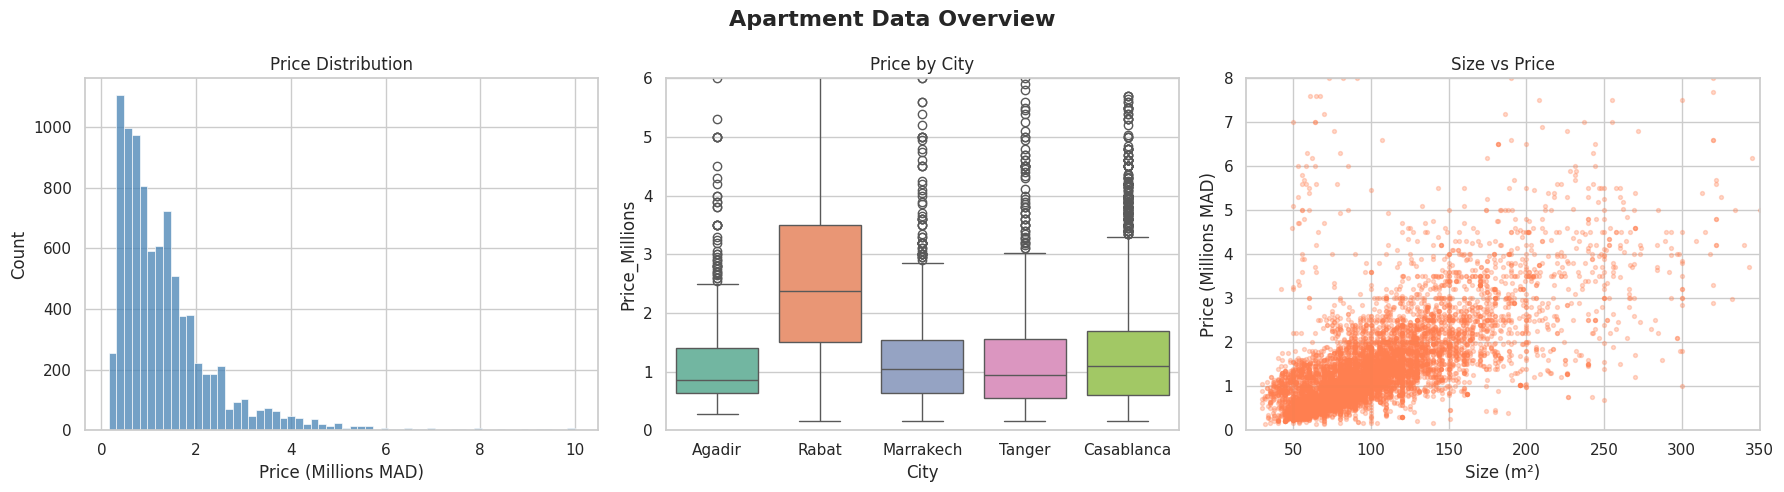

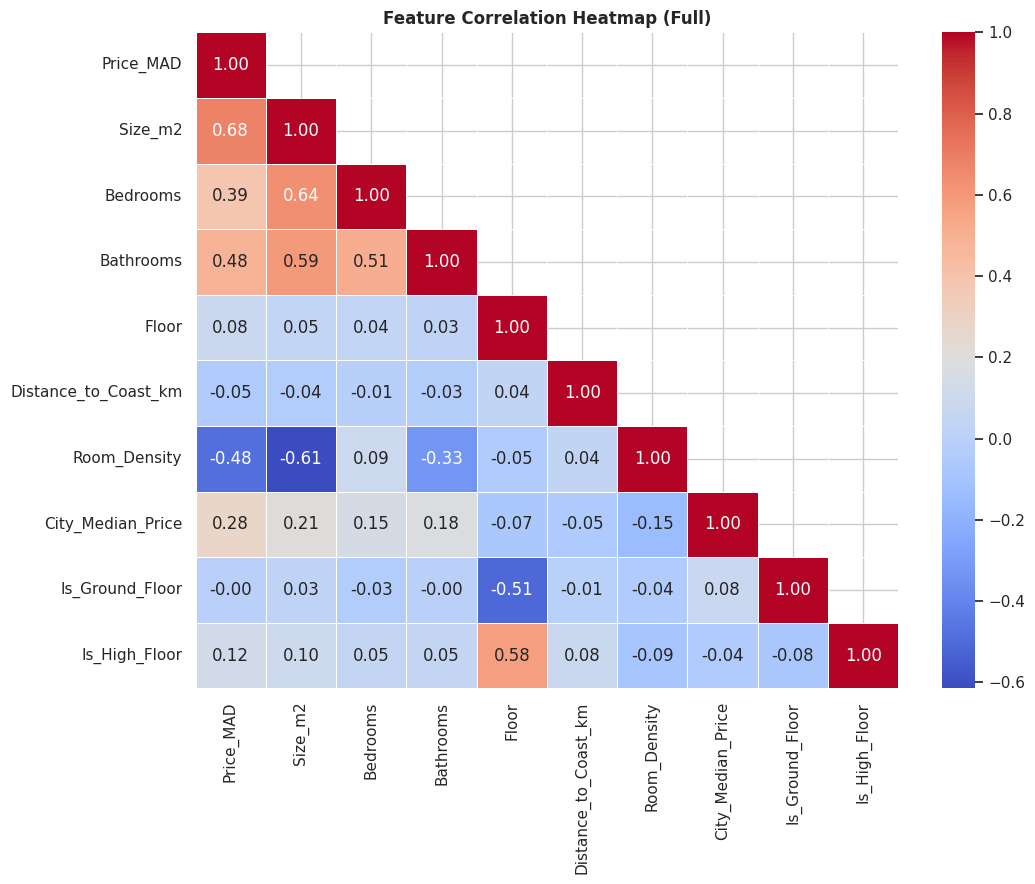

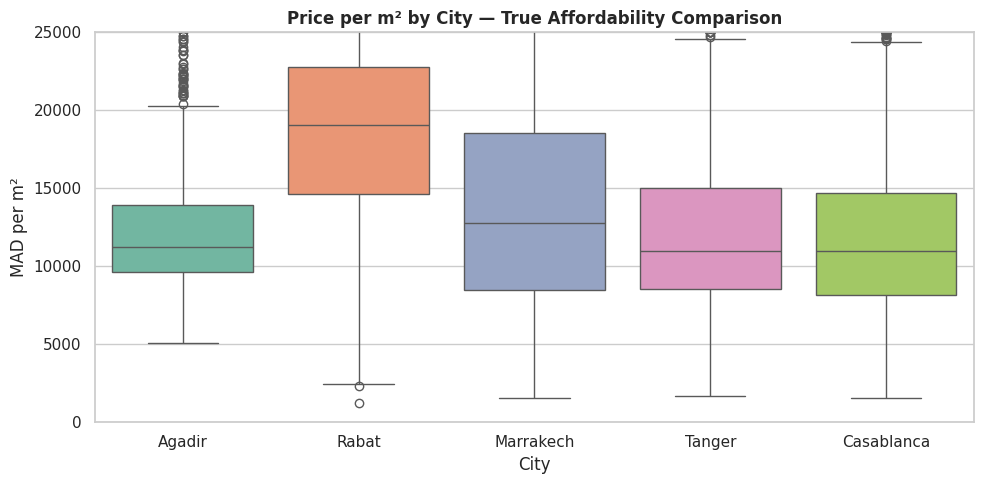

In [ ]:
# ============================================================
# STEP 5: QUICK LOOK AT THE DATA BEFORE MODELING
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("avito_ml_ready.csv")
df['Price_Millions'] = df['Price_MAD'] / 1_000_000

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Apartment Data Overview", fontsize=16, fontweight='bold')

# Chart 1: Price distribution
sns.histplot(df['Price_Millions'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (Millions MAD)")

# Chart 2: Price by City (box plot)
sns.boxplot(x='City', y='Price_Millions', data=df, ax=axes[1], palette='Set2',
            hue='City', legend=False)
axes[1].set_title("Price by City")
axes[1].set_ylim(0, 6)

# Chart 3: Size vs Price scatter
axes[2].scatter(df['Size_m2'], df['Price_Millions'], alpha=0.3, s=8, c='coral')
axes[2].set_title("Size vs Price")
axes[2].set_xlabel("Size (m²)")
axes[2].set_ylabel("Price (Millions MAD)")
axes[2].set_xlim(20, 350)
axes[2].set_ylim(0, 8)

plt.tight_layout()
plt.show()

# chart3: Correlation heatmap
plt.figure(figsize=(11, 9))
numeric_cols = ['Price_MAD', 'Size_m2', 'Bedrooms', 'Bathrooms', 'Floor', 'Distance_to_Coast_km',
                'Room_Density', 'City_Median_Price', 'Is_Ground_Floor', 'Is_High_Floor']
corr = df[numeric_cols].corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, k=1)] = True  # hide upper triangle (redundant)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, mask=mask)
plt.title("Feature Correlation Heatmap (Full)", fontweight='bold')
plt.tight_layout()
plt.show()

# chart 4: Price per m² by city — shows where is truly expensive
plt.figure(figsize=(10, 5))
sns.boxplot(x='City', y='Price_per_m2', data=df,
            hue='City', legend=False, palette='Set2')
plt.ylim(0, 25000)
plt.title("Price per m² by City — True Affordability Comparison", fontweight='bold')
plt.ylabel("MAD per m²")
plt.xlabel("City")
plt.tight_layout()
plt.show()

# **data quality check + More Data Cleaning**

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("avito_ml_ready.csv")

print(f"Rows before smart filtering: {len(df)}")
# data quality check
df['Price_per_m2'] = df['Price_MAD'] / df['Size_m2']

print("\nPrice per m² stats by city (before filter):")
print(df.groupby('City')['Price_per_m2'].describe().round(0)[['min','25%','50%','75%','max']])

# Remove listings with impossible price/m² ratios
df = df[(df['Price_per_m2'] >= 3000) & (df['Price_per_m2'] <= 35000)]

# removes the top/bottom 1% within each city separately
def remove_city_outliers(group):
    q_low  = group['Price_MAD'].quantile(0.01)
    q_high = group['Price_MAD'].quantile(0.99)
    return group[(group['Price_MAD'] >= q_low) & (group['Price_MAD'] <= q_high)]

df = df.groupby('City', group_keys=False).apply(remove_city_outliers)

# Drop the helper column
df = df.drop(columns=['Price_per_m2'])

print(f"\nRows after smart filtering: {len(df)}")
print(f"Removed: {9018 - len(df)} listings")

print("\nPrice stats after cleaning (MAD):")
print(df.groupby('City')['Price_MAD'].describe().round(0)[['min','50%','max']])

df.to_csv("avito_ml_ready.csv", index=False)

Rows before smart filtering: 9018

Price per m² stats by city (before filter):
               min      25%      50%      75%       max
City                                                   
Agadir      5062.0   9655.0  11207.0  13942.0  140000.0
Casablanca  1587.0   8182.0  11009.0  14688.0  146154.0
Marrakech   1538.0   8505.0  12806.0  18539.0  184000.0
Rabat       1214.0  14650.0  19065.0  22796.0  116923.0
Tanger      1656.0   8571.0  11000.0  15000.0  120000.0

Rows after smart filtering: 8693
Removed: 325 listings

Price stats after cleaning (MAD):
                 min        50%        max
City                                      
Agadir      400000.0   850000.0  3500000.0
Casablanca  260000.0  1075250.0  4500000.0
Marrakech   330000.0  1040000.0  3650000.0
Rabat       400000.0  2300000.0  6800000.0
Tanger      280000.0   940000.0  4500000.0


/tmp/ipykernel_1146/1707824750.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('City', group_keys=False).apply(remove_city_outliers)


# **Preparing for ML, Encoding and Splitting**

In [ ]:
# STEP 6: PREPARE FEATURES FOR MACHINE LEARNING
# ============================================================
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_csv("avito_ml_ready.csv")
df['Log_Price'] = np.log(df['Price_MAD'])
df['Price_per_m2'] = df['Price_MAD'] / df['Size_m2']

# City one-hot encoding
city_dummies = pd.get_dummies(df['City'], prefix='City', drop_first=True)
df = pd.concat([df, city_dummies], axis=1)

# Listing status ordinal encoding
status_map = {'Stale': 0, 'Standard': 1, 'Fresh': 2}
df['Status_Encoded'] = df['Listing_Status'].map(status_map)

city_cols = [c for c in df.columns if c.startswith('City_')]

feature_cols = ['Size_m2', 'Bedrooms', 'Bathrooms', 'Floor',
                'Distance_to_Coast_km', 'Status_Encoded',
                'Is_Ground_Floor', 'Is_High_Floor',
                'Room_Density', 'Has_Multiple_Bathrooms',
                'City_Median_Price'] + city_cols

X = df[feature_cols + ['Neighborhood', 'Price_per_m2']]
y = df['Log_Price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# NEIGHBORHOOD ENCODING
# Compute 4 neighborhood stats using ONLY training data (no leakage)
train_with_target = X_train.copy()
train_with_target['Log_Price']    = y_train.values
train_with_target['Price_per_m2'] = X_train['Price_per_m2'].values

neigh_stats = train_with_target.groupby('Neighborhood').agg(
    Neigh_Median_LogPrice  = ('Log_Price',    'median'),  # location price level
    Neigh_Median_PricePerM2= ('Price_per_m2', 'median'),  # price density
    Neigh_Listing_Count    = ('Log_Price',    'count'),   # how active is this area
    Neigh_Price_Std        = ('Log_Price',    'std')      # how variable are prices
).reset_index()

# Fill std NaN
neigh_stats['Neigh_Price_Std'] = neigh_stats['Neigh_Price_Std'].fillna(0)

X_train = X_train.merge(neigh_stats, on='Neighborhood', how='left')
X_test  = X_test.merge(neigh_stats,  on='Neighborhood', how='left')

global_defaults = {
    'Neigh_Median_LogPrice':   y_train.median(),
    'Neigh_Median_PricePerM2': X_train['Neigh_Median_PricePerM2'].median(),
    'Neigh_Listing_Count':     1,
    'Neigh_Price_Std':         X_train['Neigh_Price_Std'].median()
}
for col, val in global_defaults.items():
    X_train[col] = X_train[col].fillna(val)
    X_test[col]  = X_test[col].fillna(val)

X_train = X_train.drop(columns=['Neighborhood', 'Price_per_m2'])
X_test  = X_test.drop(columns=['Neighborhood', 'Price_per_m2'])

X_train = X_train.astype(float)
X_test  = X_test.astype(float)

y_train_np = np.array(y_train).ravel()
y_test_np  = np.array(y_test).ravel()
y_true_np  = np.exp(y_test_np)

final_features = X_train.columns.tolist()
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Total features   : {len(final_features)}")
print(f"\nFeatures:\n{final_features}")

Training samples : 6954
Test samples     : 1739
Total features   : 20

Features:
['Size_m2', 'Bedrooms', 'Bathrooms', 'Floor', 'Distance_to_Coast_km', 'Status_Encoded', 'Is_Ground_Floor', 'Is_High_Floor', 'Room_Density', 'Has_Multiple_Bathrooms', 'City_Median_Price', 'City_Median_Price', 'City_Casablanca', 'City_Marrakech', 'City_Rabat', 'City_Tanger', 'Neigh_Median_LogPrice', 'Neigh_Median_PricePerM2', 'Neigh_Listing_Count', 'Neigh_Price_Std']


# **Model 1: Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X_train = X_train.astype(float)
X_test  = X_test.astype(float)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = np.exp(lr.predict(X_test))
y_true    = np.exp(y_test)

lr_mae = mean_absolute_error(y_true, y_pred_lr)
lr_r2  = r2_score(y_true, y_pred_lr)

print("=" * 40)
print("  LINEAR REGRESSION ")
print("=" * 40)
print(f"  R² Score : {lr_r2:.4f} ")
print(f"  MAE      : {lr_mae:,.0f} MAD")
print(f"  → On average, predictions are off by {lr_mae/1000:.0f}k MAD")

  LINEAR REGRESSION 
  R² Score : 0.8088 
  MAE      : 236,354 MAD
  → On average, predictions are off by 236k MAD


# **Model 2: Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X_train = X_train.astype(float)
X_test  = X_test.astype(float)

rf = RandomForestRegressor(n_estimators=300, max_depth=12,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = np.exp(rf.predict(X_test))

rf_mae = mean_absolute_error(y_true, y_pred_rf)
rf_r2  = r2_score(y_true, y_pred_rf)

print("=" * 40)
print("  RANDOM FOREST")
print("=" * 40)
print(f"  R² Score : {rf_r2:.4f}")
print(f"  MAE      : {rf_mae:,.0f} MAD")
print(f"  → On average, predictions are off by {rf_mae/1000:.0f}k MAD")

  RANDOM FOREST
  R² Score : 0.8598
  MAE      : 208,634 MAD
  → On average, predictions are off by 209k MAD


# **Model 3: XGBoost**

In [ ]:
from xgboost import XGBRegressor
import numpy as np

X_train_xgb = X_train.astype(float).values  # .values converts to numpy array
X_test_xgb  = X_test.astype(float).values
y_train_np   = np.array(y_train).ravel()     # ravel() flattens it to 1D
y_test_np    = np.array(y_test).ravel()

print("Shapes:")
print(f"  X_train: {X_train_xgb.shape}")
print(f"  y_train: {y_train_np.shape}")

xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.75,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=67,
    n_jobs=-1,
    early_stopping_rounds=75
)

xgb.fit(X_train_xgb, y_train_np,
        eval_set=[(X_test_xgb, y_test_np)],
        verbose=100)

y_pred_xgb = np.exp(xgb.predict(X_test_xgb))
y_true_np   = np.exp(y_test_np)

xgb_mae = mean_absolute_error(y_true_np, y_pred_xgb)
xgb_r2  = r2_score(y_true_np, y_pred_xgb)

print("\n" + "=" * 40)
print("  XGBOOST")
print("=" * 40)
print(f"  R² Score : {xgb_r2:.4f}")
print(f"  MAE      : {xgb_mae:,.0f} MAD")
print(f"  → On average, predictions are off by {xgb_mae/1000:.0f}k MAD")

Shapes:
  X_train: (6954, 20)
  y_train: (6954,)
[0]	validation_0-rmse:0.63564
[100]	validation_0-rmse:0.25633
[200]	validation_0-rmse:0.23565
[300]	validation_0-rmse:0.23347
[400]	validation_0-rmse:0.23279
[500]	validation_0-rmse:0.23234
[600]	validation_0-rmse:0.23220
[632]	validation_0-rmse:0.23226

  XGBOOST
  R² Score : 0.8581
  MAE      : 210,355 MAD
  → On average, predictions are off by 210k MAD


# **Model Comparison, STACK RF + XGBOOST**

  RF + XGBOOST STACK
  R² Score : 0.8626
  MAE      : 206,333 MAD
  → On average, predictions are off by 206k MAD

=== FINAL MODEL COMPARISON ===
            Model  R² Score     MAE (MAD)
   RF + XGB Stack  0.862619 206333.140704
    Random Forest  0.859842 208634.160625
          XGBoost  0.858124 210354.888675
Linear Regression  0.808760 236353.688929


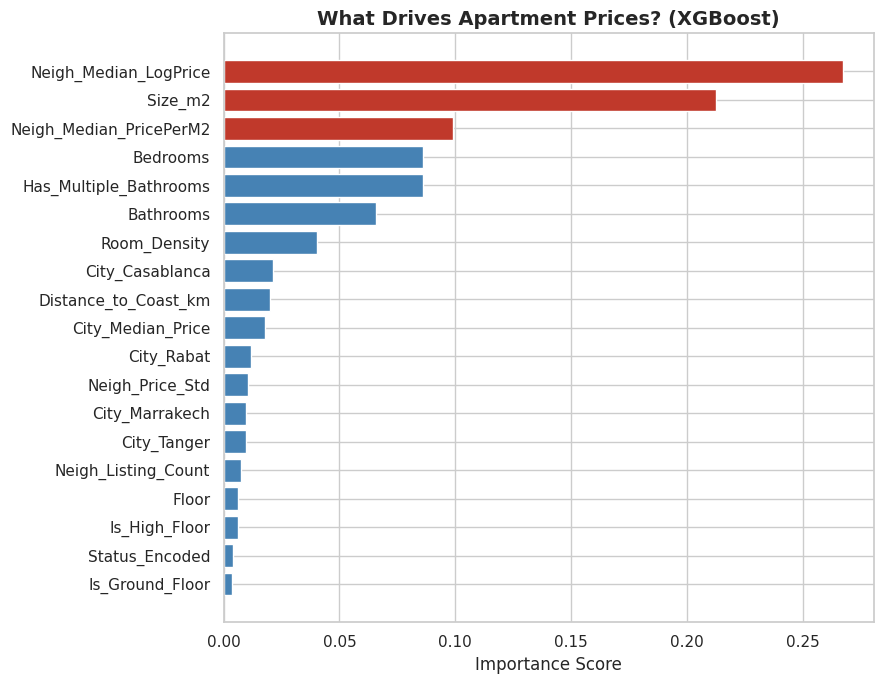

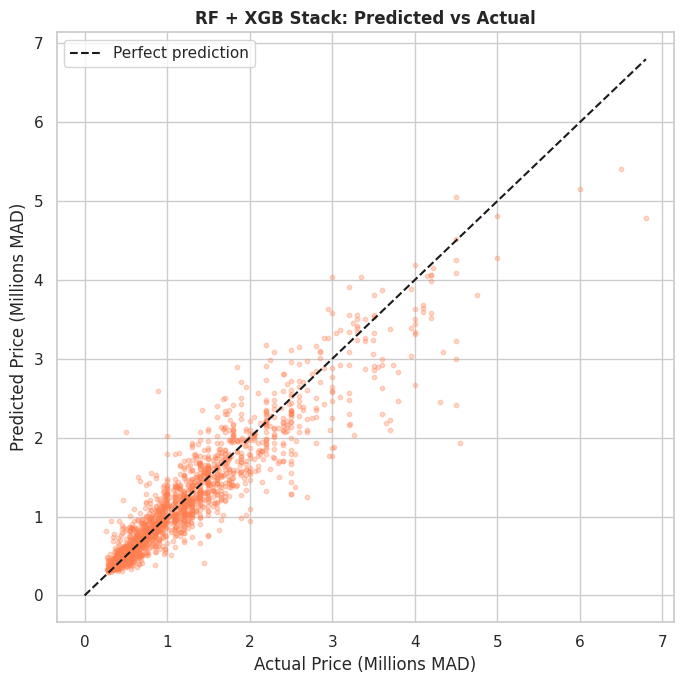

In [ ]:
# STEP 10: STACK RF + XGBOOST + COMPARE ALL MODELS
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# --- Stacked Ensemble: average the two best models ---
y_pred_stack = (y_pred_rf + y_pred_xgb) / 2

stack_mae = mean_absolute_error(y_true_np, y_pred_stack)
stack_r2  = r2_score(y_true_np, y_pred_stack)

print("=" * 40)
print("  RF + XGBOOST STACK")
print("=" * 40)
print(f"  R² Score : {stack_r2:.4f}")
print(f"  MAE      : {stack_mae:,.0f} MAD")
print(f"  → On average, predictions are off by {stack_mae/1000:.0f}k MAD")

# --- Model Comparison Table ---
results = pd.DataFrame({
    'Model':     ['Linear Regression', 'Random Forest', 'XGBoost', 'RF + XGB Stack'],
    'R² Score':  [lr_r2, rf_r2, xgb_r2, stack_r2],
    'MAE (MAD)': [lr_mae, rf_mae, xgb_mae, stack_mae]
})
results = results.sort_values('R² Score', ascending=False)
print("\n=== FINAL MODEL COMPARISON ===")
print(results.to_string(index=False))

# --- Feature Importance ---
feat_importance = pd.DataFrame({
    'Feature':    final_features,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 7))
colors = ['#c0392b' if i >= len(final_features)-3 else 'steelblue'
          for i in range(len(feat_importance))]
plt.barh(feat_importance['Feature'], feat_importance['Importance'],
         color=colors, edgecolor='white')
plt.title("What Drives Apartment Prices? (XGBoost)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# --- Predicted vs Actual (best model) ---
best_pred = y_pred_stack if stack_r2 > xgb_r2 else y_pred_xgb
best_name = "RF + XGB Stack" if stack_r2 > xgb_r2 else "XGBoost"

plt.figure(figsize=(7, 7))
plt.scatter(y_true_np / 1_000_000, best_pred / 1_000_000,
            alpha=0.3, s=10, color='coral')
max_val = max(y_true_np.max(), best_pred.max()) / 1_000_000
plt.plot([0, max_val], [0, max_val], 'k--', lw=1.5, label='Perfect prediction')
plt.xlabel("Actual Price (Millions MAD)")
plt.ylabel("Predicted Price (Millions MAD)")
plt.title(f"{best_name}: Predicted vs Actual", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# **HOW PRECISE IS THE MODEL?**

  MODEL PRECISION (PERCENTAGE ERRORS)
  MAPE  (mean % error)   : 17.4%
  MAPE (median % error) : 12.6%
  Within 10% of real price : 41.7% of listings
  Within 15% of real price : 56.1% of listings
  Within 20% of real price : 67.3% of listings
  Within 25% of real price : 78.0% of listings
  Within 30% of real price : 85.3% of listings

--- Precision by Price Tier ---
Tier         Price Range                MAPE   Within 20%
--------------------------------------------------------
Budget       < 1M MAD                  19.4%        64.4%
Mid          1M – 2.5M MAD             15.1%        70.6%
Luxury       > 2.5M MAD                16.6%        68.5%


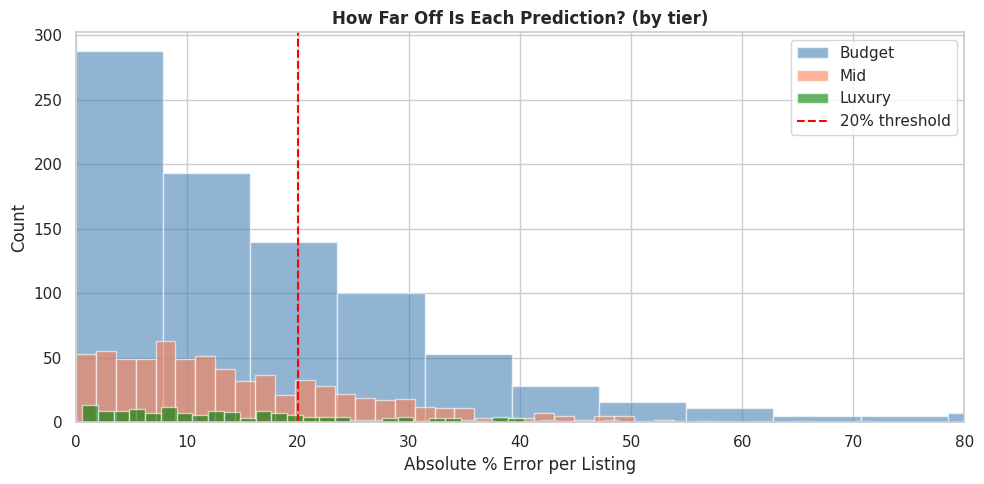

In [ ]:
# HOW PRECISE IS THE MODEL? — PERCENTAGE ERROR BREAKDOWN
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

y_actual    = y_true_np
y_predicted = y_pred_stack

pct_errors = np.abs(y_actual - y_predicted) / y_actual * 100

mape = pct_errors.mean()
median_pct = np.median(pct_errors)

print("=" * 45)
print("  MODEL PRECISION (PERCENTAGE ERRORS)")
print("=" * 45)
print(f"  MAPE  (mean % error)   : {mape:.1f}%")
print(f"  MAPE (median % error) : {median_pct:.1f}%")

for threshold in [10, 15, 20, 25, 30]:
    pct_within = (pct_errors <= threshold).mean() * 100
    print(f"  Within {threshold}% of real price : {pct_within:.1f}% of listings")

# Breakdown by price tier
print("\n--- Precision by Price Tier ---")
print(f"{'Tier':<12} {'Price Range':<22} {'MAPE':>8} {'Within 20%':>12}")
print("-" * 56)

tiers = [
    ('Budget',  y_actual < 1_000_000),
    ('Mid',    (y_actual >= 1_000_000) & (y_actual <= 2_500_000)),
    ('Luxury',  y_actual > 2_500_000)
]

for name, mask in tiers:
    if mask.sum() == 0:
        continue
    t_mape    = np.abs(y_actual[mask] - y_predicted[mask]) / y_actual[mask] * 100
    t_within  = (t_mape <= 20).mean() * 100
    price_range = {
        'Budget':  '< 1M MAD',
        'Mid':     '1M – 2.5M MAD',
        'Luxury':  '> 2.5M MAD'
    }[name]
    print(f"{name:<12} {price_range:<22} {t_mape.mean():>7.1f}% {t_within:>11.1f}%")

# Visual: error distribution by tier
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Budget': 'steelblue', 'Mid': 'coral', 'Luxury': 'green'}
for name, mask in tiers:
    if mask.sum() == 0:
        continue
    t_err = np.abs(y_actual[mask] - y_predicted[mask]) / y_actual[mask] * 100
    ax.hist(t_err, bins=40, alpha=0.6, label=name, color=colors[name])

ax.axvline(20, color='red', linestyle='--', lw=1.5, label='20% threshold')
ax.set_xlabel("Absolute % Error per Listing")
ax.set_ylabel("Count")
ax.set_title("How Far Off Is Each Prediction? (by tier)", fontweight='bold')
ax.set_xlim(0, 80)
ax.legend()
plt.tight_layout()
plt.show()